## 01 — Baseline: `treelhouette_orig_M0`

| Part    | Content |
|---------|---------|
| **Part 1** | Reproduction of the examples from the ISFS2025 presentation "Yet another graphical aid to the interpretation and validation of cluster analysis". |
| **Part 2** | Optimisation experiment: the unmodified measure is used as an objective function and its optimum is compared with the reference partitions. |

**Measure under test:** `treelhouette_orig_M0`

---

### Measure definition

**Setting.** Let $X=\{x_1,\dots,x_n\}$ be the data and $C_1,\dots,C_k$ a partition of $X$ into $k\ge 2$ clusters. Let $T=(V,E)$ be the Euclidean minimum spanning tree of $X$ ($|E|=n-1$) with edge weights $w(e)=\lVert x_u-x_v\rVert$. Here $T$ is the plain Euclidean MST (`M=0` in `quitefastmst.mst_euclid`).

Split the edges into

- **within-cluster edges** $E_{\text{in}}$: both endpoints in the same cluster,
- **cut edges** $E_{\text{cut}}=E\setminus E_{\text{in}}$: endpoints in different clusters. $E_{\text{cut}}(j)$ denotes the cut edges with exactly one endpoint in $C_j$.

**Edge-level quantities.** For every $e\in E_{\text{in}}$ lying in cluster $C_j$:

$$a_e = w(e), \qquad b_j = \min_{e'\in E_{\text{cut}}(j)} w(e')$$

$$t_e=\begin{cases} 1-\dfrac{a_e}{b_j} & a_e<b_j,\\[4pt] 0 & a_e=b_j,\\[4pt] \dfrac{b_j}{a_e}-1 & a_e>b_j,\end{cases}
% \qquad\text{i.e.}\quad t_e=\frac{b_j-a_e}{\max(a_e,\,b_j)}\in[-1,1].$$

**Score.**

$$\text{treelhouette\_orig}(X,C)=\frac{1}{|E_{\text{in}}|}\sum_{e\in E_{\text{in}}} t_e .$$

**What is and is not computed**

- Only within-cluster edges receive a value $t_e$. Cut edges are not scored ($b$ is undefined for an edge that belongs to no single cluster).
- A **singleton cluster** has no within-cluster edge, so it contributes nothing to the score.
- The presentation defines the measure for partitions obtained by removing $k-1$ edges of the MST (every cluster is a connected subtree, $|E_{\text{cut}}|=k-1$). **Here the formula is applied to any partition, without validation.** Then $|E_{\text{cut}}|$ can exceed $k-1$, and $b_j$ is the minimum over all cut edges touching $C_j$. Example: the reference labelling of `wut/x2` ($k=3$) has 9 cut edges instead of 2.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import DATA_PATH, RESULT_PATH

MEASURE_NAME = "treelhouette_orig_M0" 
RESULT_PATH = RESULT_PATH / MEASURE_NAME

In [2]:
import clustbench

from sklearn.metrics import silhouette_score
from mstcvi import treelhouette_score

from scripts.experiment_runner import run_optimization_experiment
from scripts.utils import plot_treelhouette_summary, plot_benchmark_treelhouette_summaries

---

### Part 1 — Reproduction of the presentation results

Reproduces the examples from M. Gągolewski, *"Yet another graphical aid to the interpretation and validation of cluster analysis"* (ISFS2025). For each dataset we print the classic silhouette score next to `treelhouette_orig` and draw the diagnostic figure.

Data are loaded with the `clustbench` defaults (`preprocess=True`: centred, scaled to total variance 1, tiny noise added), as in Part 2.

**sipu/jain**

In [3]:
battery = "sipu"
dataset = "jain"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)

In [4]:
s = silhouette_score(b.data, b.labels[0])
print(f"Silhouette score: {s:.4f}")

t = treelhouette_score(b.data, b.labels[0])
print(f"Treelhouette score: {t:.4f}")

Silhouette score: 0.4025
Treelhouette score: 0.7370


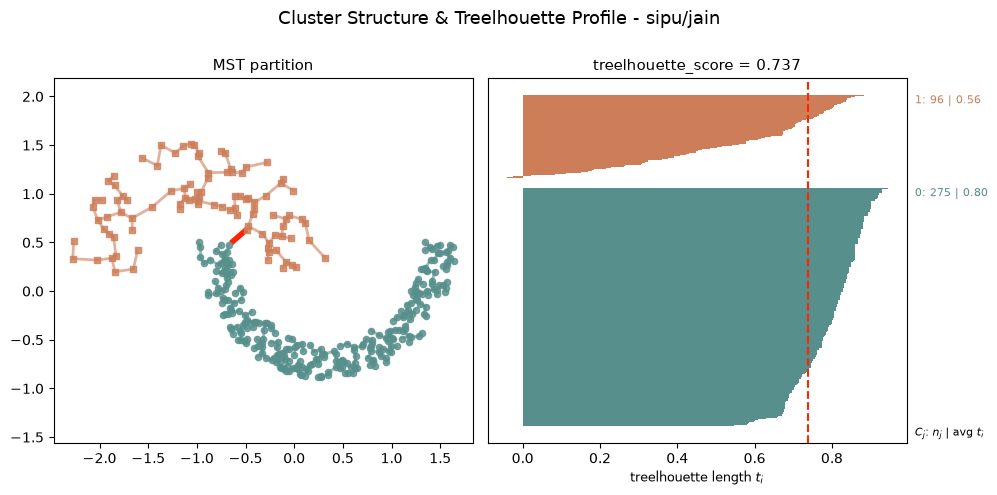

In [5]:
plot_treelhouette_summary(b.data, b.labels[0], title="Cluster Structure & Treelhouette Profile - sipu/jain");

**wut/windows**

In [6]:
battery = "wut"
dataset = "windows"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)

In [7]:
s = silhouette_score(b.data, b.labels[0])
print(f"Silhouette score: {s:.4f}")

t = treelhouette_score(b.data, b.labels[0])
print(f"Treelhouette score: {t:.4f}")

Silhouette score: -0.1252
Treelhouette score: 0.9156


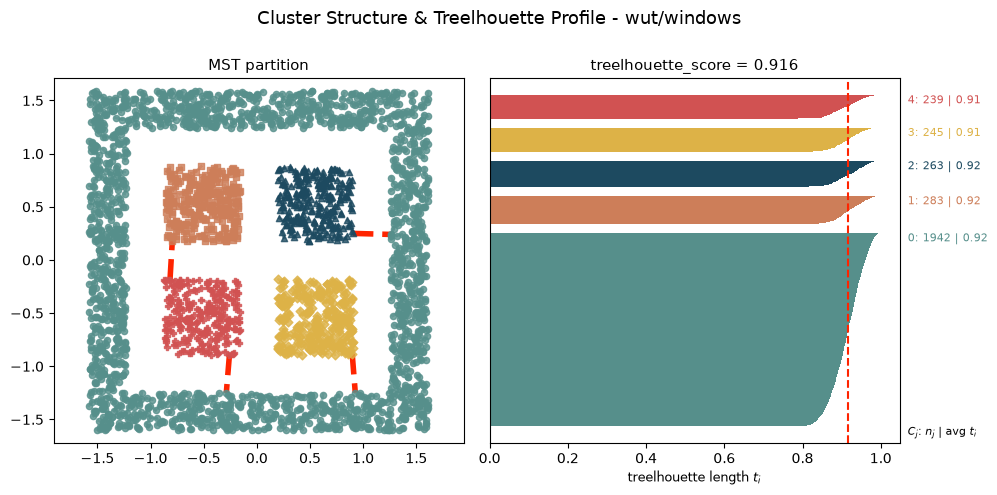

In [8]:
plot_treelhouette_summary(b.data, b.labels[0], title="Cluster Structure & Treelhouette Profile - wut/windows");

**wut/x2**

In [9]:
battery = "wut"
dataset = "x2"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)

In [10]:
s = silhouette_score(b.data, b.labels[0])
print(f"Silhouette score: {s:.4f}")

t = treelhouette_score(b.data, b.labels[0])
print(f"Treelhouette score: {t:.4f}")

Silhouette score: 0.3566
Treelhouette score: 0.0827


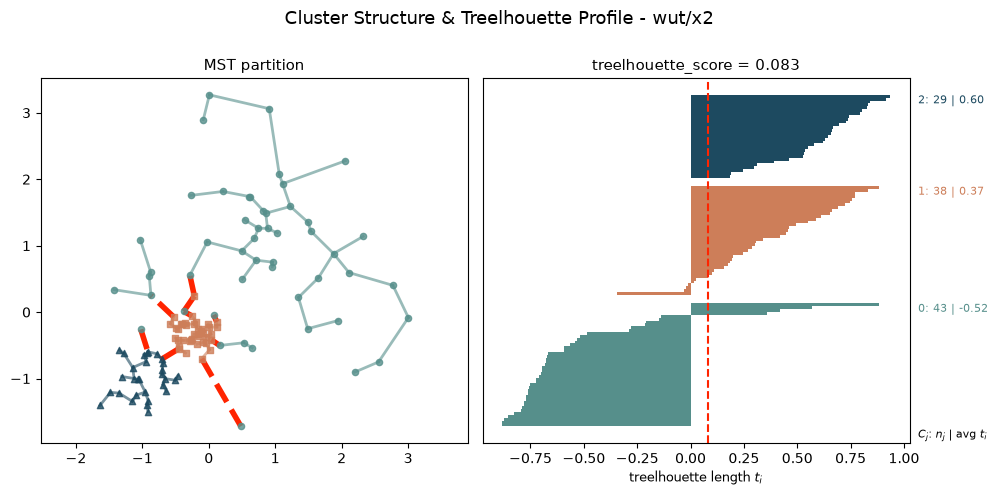

In [11]:
plot_treelhouette_summary(b.data, b.labels[0], title="Cluster Structure & Treelhouette Profile - wut/x2");

---

### Part 2 — Baseline optimisation experiment

In [ ]:
run_optimization_experiment(
    battery="fcps",
    I_func=treelhouette_score,
    I_name=MEASURE_NAME,
    data_path=DATA_PATH,
    results_dir=RESULT_PATH,
    P=100,
    n_init=5,
    random_state=42,
    skip_large=True,
    verbose=True,
)


=== fcps/atom  n=800 d=3 k=2 ===
Optimization complete!                   
    Best I(C*)               = 0.913273
    Best ARI(C*)             = 1.000000
    Best candidate name      = AC_single
    Candidates explored      = 18
    Tabu set size (|T|)      = 1800
    I_func evaluations       = 1_472_409
    Elapsed time             = 141.7s

=== fcps/chainlink  n=1000 d=3 k=2 ===
Optimization complete!                   
    Best I(C*)               = 0.942947
    Best ARI(C*)             = 1.000000
    Best candidate name      = AC_single
    Candidates explored      = 23
    Tabu set size (|T|)      = 2300
    I_func evaluations       = 2_341_485
    Elapsed time             = 272.0s

=== fcps/engytime  n=4096 d=2 k=2 ===
Optimization complete!                   
    Best I(C*)               = 0.929860
    Best ARI(C*)             = 0.000002
    Best candidate name      = AC_single
    Candidates explored      = 27
    Tabu set size (|T|)      = 2700
    I_func evaluations       =

c:\Users\olenk\OneDrive\Pulpit\Master\mstcvi\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\olenk\OneDrive\Pulpit\Master\mstcvi\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimization complete!                   
    Best I(C*)               = 0.855487
    Best ARI(C*)             = 1.000000
    Best candidate name      = KMeans_0
    Candidates explored      = 28
    Tabu set size (|T|)      = 2800
    I_func evaluations       = 3_556_310
    Elapsed time             = 203.1s

=== fcps/lsun  n=400 d=2 k=3 ===
Optimization complete!                   
    Best I(C*)               = 0.820352
    Best ARI(C*)             = 1.000000
    Best candidate name      = GaussianMixture_0
    Candidates explored      = 23
    Tabu set size (|T|)      = 2300
    I_func evaluations       = 1_840_213
    Elapsed time             = 136.3s

=== fcps/target  n=758 d=2 k=2 ===
Optimization complete!                   
    Best I(C*)               = 0.943603
    Best ARI(C*)             = 1.000000
    Best candidate name      = AC_single
    Candidates explored      = 25
    Tabu set size (|T|)      = 2500
    I_func evaluations       = 1_952_599
    Elapsed time         

,I_name,battery,dataset,n,d,k,best_score,best_ari,best_candidate_name,tabu_list_size,n_evaluations,elapsed_seconds
0,treelhouette_orig,fcps,atom,800,3,2,0.913273,1.000000,AC_single,1800,1472409,141.724075
1,treelhouette_orig,fcps,chainlink,1000,3,2,0.942947,1.000000,AC_single,2300,2341485,272.045507
2,treelhouette_orig,fcps,engytime,4096,2,2,0.929860,0.000002,AC_single,2700,11459021,3622.386728
3,treelhouette_orig,fcps,hepta,212,3,7,0.855487,1.000000,KMeans_0,2800,3556310,203.117449
4,treelhouette_orig,fcps,lsun,400,2,3,0.820352,1.000000,GaussianMixture_0,2300,1840213,136.313703
5,treelhouette_orig,fcps,target,758,2,2,0.943603,1.000000,AC_single,2500,1952599,193.383384
6,treelhouette_orig,fcps,tetra,400,3,4,0.479607,0.000000,AC_single,2601,3122604,232.887208
7,treelhouette_orig,fcps,twodiamonds,800,2,2,0.642691,0.000000,AC_single,1300,1076863,108.627233
8,treelhouette_orig,fcps,wingnut,1016,2,2,0.743833,1.000000,AC_single,1800,1877213,218.506463


#### Visual review of the optimum (2D datasets only)

Loads the best partition $C^*$ of every saved run and draws the two-panel diagnostic figure.


=== fcps/engytime n=4096 d=2 k=2 ARI=0.000 ===


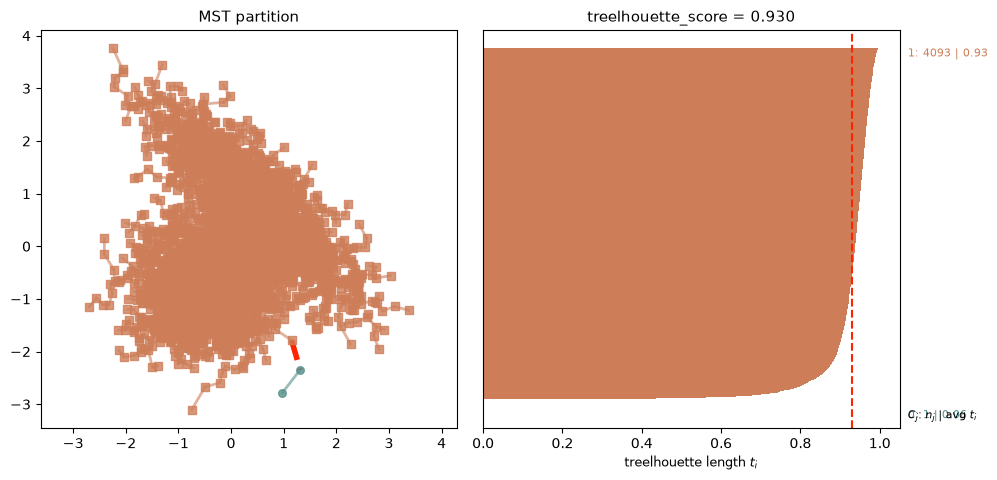


=== fcps/lsun n=400 d=2 k=3 ARI=1.000 ===


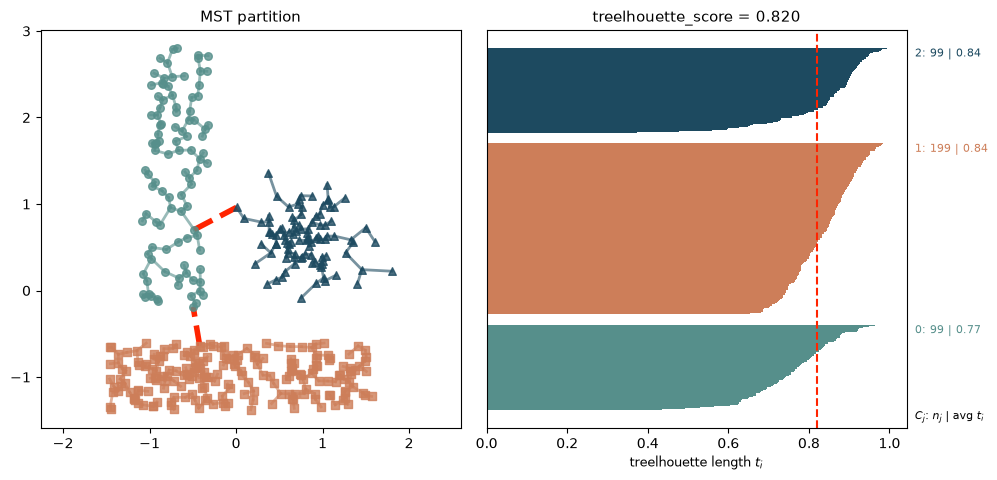


=== fcps/target n=758 d=2 k=2 ARI=1.000 ===


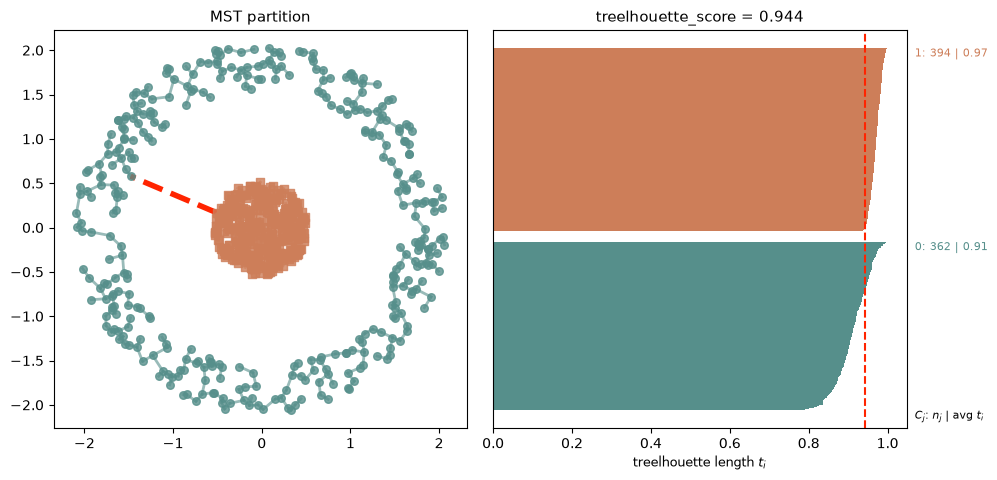


=== fcps/twodiamonds n=800 d=2 k=2 ARI=0.000 ===


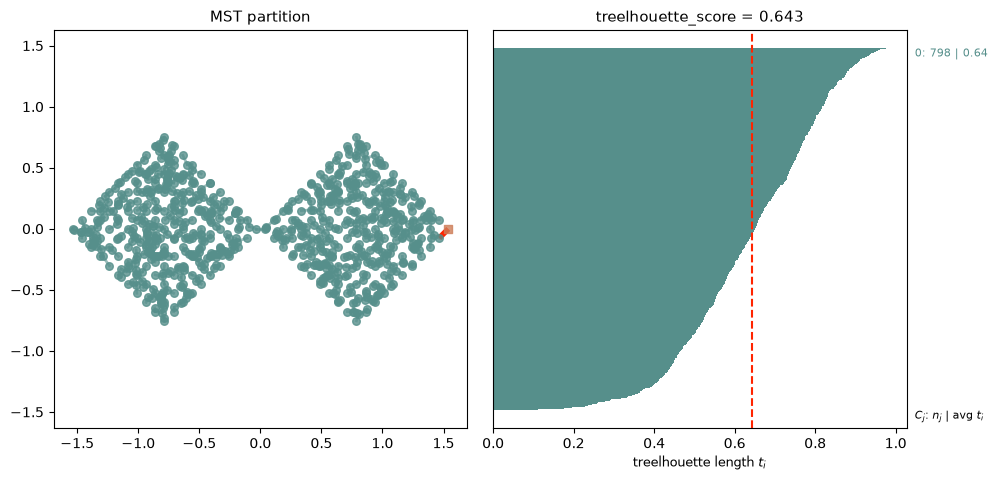


=== fcps/wingnut n=1016 d=2 k=2 ARI=1.000 ===


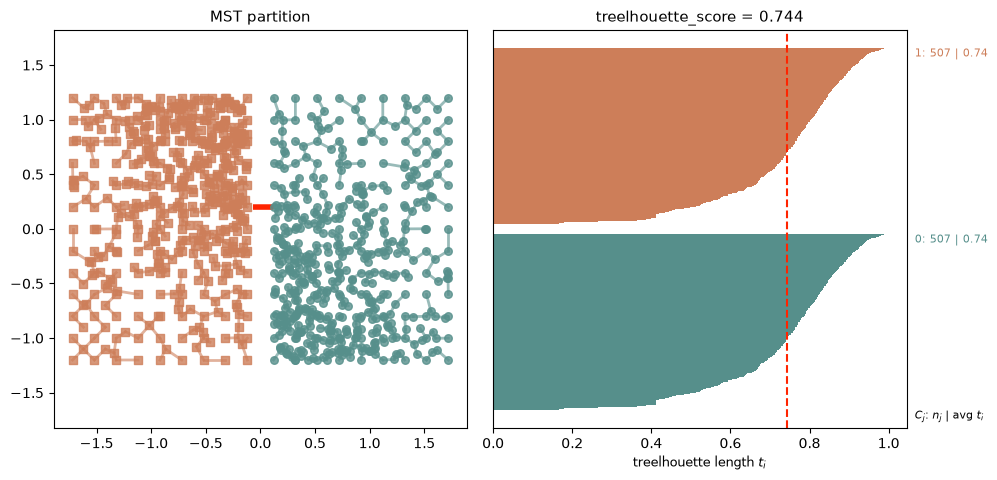

In [ ]:
plot_benchmark_treelhouette_summaries(
    batteries="fcps", 
    data_path=DATA_PATH, 
    result_path=RESULT_PATH, 
    point_size=30
)